In [112]:
import numpy as np 
import matplotlib.pyplot as plt
import math


In [32]:

# beta = alpha defined in my CPB
beta=5
Ej=0.2
Ec=Ej*beta
ng=0.5
hbar=1.05*10**(-34)
hbar=2*np.pi
m=hbar/8/beta
w=np.sqrt(1/m)
alpha=m*w/hbar
Phi0 = lambda x: (alpha/np.pi)**0.25 *np.exp(-alpha*x**2/2)
N=1000
S=np.pi
x = np.linspace(-S,S,num=N)
d=x[1]-x[0]

phi0 = np.array([Phi0(var) for var in x])


V=np.zeros([N,N],dtype=complex)

D=V
for i in range(N):
    D[i,i]= 4*Ec*ng**2 -Ej -Ej*x[i]**4/24

U=V
for i in range(N-1):
    U[i,i+1]= 1j*8*Ec*ng/d/2

L=V
for i in range(N-1):
    L[i+1,i]= -1j*8*Ec*ng/d/2

V=U+D+L

E=phi0 @V @phi0
hbar*w/2+E*d
# E*d

np.complex128(9.411369015225745-8.937881236138186e-16j)

In [148]:
def testn(ng,n,isE=False):
    # beta = alpha defined in my CPB
    beta=1
    Ej=0.2
    Ec=Ej*beta
    #ng=0.5
    # hbar=1.05*10**(-34)
    hbar=2*np.pi
    m=hbar/8/Ec
    w=np.sqrt(Ej/m)
    alpha=m*w/hbar
    c=[0 for i in range(n)];c.append(1)
    Phi = lambda xi: (alpha/np.pi)**0.25 *np.exp(-xi**2/2)*np.polynomial.hermite.hermval(xi,c)/np.sqrt(math.factorial(n)*2**n)
    N=1000
    S=2
    x = np.linspace(-S,S,num=N)
    d=x[1]-x[0]

    xi=alpha*x
    phi = np.array([Phi(var) for var in alpha*x])


    V=np.zeros([N,N],dtype=complex)

    D=V
    for i in range(N):
        D[i,i]= 4*Ec*ng**2 -Ej -Ej*x[i]**4/24

    U=V
    for i in range(N-1):
        U[i,i+1]= 1j*8*Ec*ng/d/2

    L=V
    for i in range(N-1):
        L[i+1,i]= -1j*8*Ec*ng/d/2

    V=U+D+L
    E=phi @V @phi
    if(isE):
        return E*d+hbar*w*(n+1/2)
    return E*d
# E*d


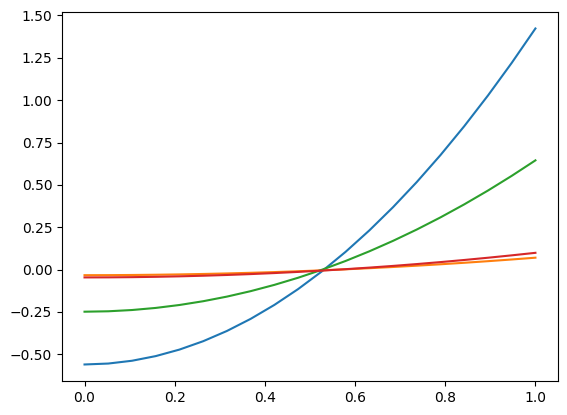

In [149]:
ngsweep=np.linspace(0,1,20)
plt.plot(hbsweep,[[testn(i,j) for j in range(4)] for i in ngsweep])

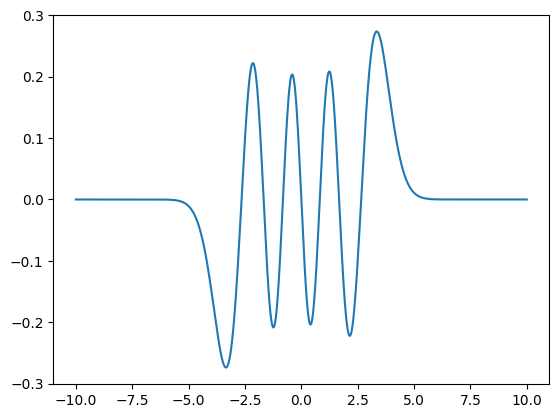

In [151]:
S=10
x=np.linspace(-S,S,1000)
n=7
c=[0 for i in range(n)];c.append(1)
Phi = lambda xi: (alpha/np.pi)**0.25 *np.exp(-xi**2/2)*np.polynomial.hermite.hermval(xi,c)/np.sqrt(math.factorial(n)*2**n)
plt.plot(x,Phi(x))